# Test the sample and distributional accuracy of the GNN-based probabilistic models

In [43]:
import numpy as np
import torch
from torchvision import transforms
import numpy as np
import tqdm

import dgn4cfd as dgn 

from dgn4cfd.datasets_3 import *

In [44]:
device = torch.device('cpu')

Settings:

In [45]:
#DATASET = dgn.datasets.DatasetUrl.pOnWingInDist
NUM_DENOISING_STEPS = 30
SIM_IDX = 3

Load the models:
- Diffusion Graph Net (DGN)
- Latent Diffusion Graph Net (LDGN)

In [46]:
# Diffusion Graph Net
DGN = dgn.nn.DiffusionGraphNet(
    checkpoint = "/home/kanadsen01/Desktop/Git_repos/Forked_Repos/dgn4cfd_tum/examples/ARO/checkpoints/DGNN_3_64_layers.chk",
    device     = device,
)

# Latent Diffusion Graph Net
#LDGN = dgn.nn.LatentDiffusionGraphNet(
#    autoencoder_checkpoint = "./checkpoints/ae-nt250.chk",
#    checkpoint             = "./checkpoints/ldgn-nt250.chk",
#    device                 = device,
#)

# Flow Matching Graph Net
#FMGN = dgn.nn.FlowMatchingGraphNet(
#    checkpoint = "./checkpoints/fmgn-nt250.chk",
#    device     = device,
#)

Load a dataset

In [47]:
transform = transforms.Compose([
    dgn.transforms.ConnectKNN(6),
    #dgn.transforms.ScaleEdgeAttr(0.015),                        # Scale the relative position stored as `edge_attr`
    #dgn.transforms.EdgeCondFreeStream(normals='loc'),           # Add the projection of the free stream velocity along edge-local axes as `edge_cond`
    dgn.transforms.ScaleAttr('target', vmin=2.5e+03,  vmax=1.5e+05),  # Scale the target field (pressure)
    dgn.transforms.ScaleAttr('glob', vmin=4,  vmax=5),  # Scale the target field (pressure)
    dgn.transforms.ScaleAttr('loc', vmin=203,  vmax=600),  # Scale the target field (pressure)
    dgn.transforms.MeshCoarsening(                              # Create 5 lower-resolution graphs and normalise the relative position betwen the inter-graph nodes.
        num_scales      = 4,
        rel_pos_scaling = [0.015, 0.03, 0.06, 0.12], #  
        scalar_rel_pos  = True, 
    ),
])
dataset = Shock(
    path      = "/home/kanadsen01/Desktop/Git_repos/Forked_Repos/dgn4cfd_tum/data/dataset_trial1",
    T         = 1,
    transform = transform,
    preload   = False,
)
print('Number of samples:', len(dataset))

T = 1 # The grouth-truth trajectory length

Number of samples: 104


## Sample Inference
We sample from the distribution learned by each model, given the conditioning node and edge features. To compute the sample accuracy (coefficient of determination in this case), we find in the dataset the ground-truth sample closest to the predicted sample.

====== DGN ======
R2: -14.7527 at t=0


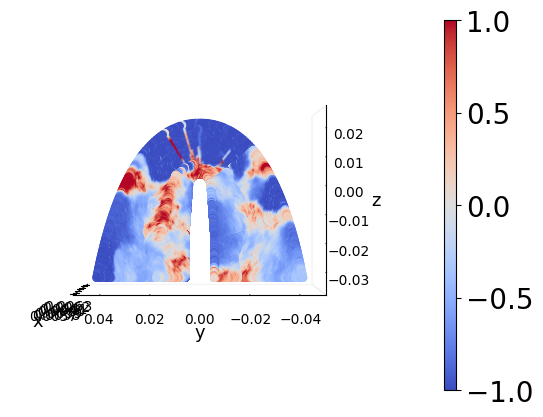

'\n# LDGN inference\nsteps = dgn.nn.diffusion.DiffusionStepsGenerator(\'linear\', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS) # Sample denoising steps for the DGN and LDGN\npred = LDGN.sample(graph, steps=steps)\n\n# Compute the accuracy\ntargets = graph.target.split(1, dim=1)\nr2 = [dgn.metrics.r2_accuracy(pred, target) for target in targets]\nr2, t = np.max(r2), np.argmax(r2)\ntarget = targets[t] # Ground-truth field closest to the prediction\nprint(\'====== LDGN ======\')\nprint(f"R2: {r2:.4f} at t={t}")\n\n# Plot the results\ngraph.plot_pos_field(pred[:,0], s=20, azim=180, elev=110)\n\n\n# FMGN inference\nsteps = np.linspace(0, 1, NUM_DENOISING_STEPS + 1)\npred = FMGN.sample(graph, steps=steps)\n\n# Compute the accuracy\ntargets = graph.target.split(1, dim=1)\nr2 = [dgn.metrics.r2_accuracy(pred, target) for target in targets]\nr2, t = np.max(r2), np.argmax(r2)\ntarget = targets[t] # Ground-truth field closest to the prediction\nprint(\'====== FMGN ======\')\nprint(f"R2: {

In [48]:
graph = dataset.get_sequence(SIM_IDX, n_in=T)


# DGN inference
steps = dgn.nn.diffusion.DiffusionStepsGenerator('linear', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS) # Sample denoising steps for the DGN and LDGN
pred = DGN.sample(graph, steps=steps)

# Compute the accuracy
targets = graph.target.split(1, dim=1)
r2 = [dgn.metrics.r2_accuracy(pred, target) for target in targets]
r2, t = np.max(r2), np.argmax(r2)
target = targets[t] # Ground-truth field closest to the prediction
print('====== DGN ======')
print(f"R2: {r2:.4f} at t={t}")

# Plot the results
graph.plot_pos_field(pred[:,0], azim=180, elev=0, s=20,vmax=1,vmin=-1)

"""
# LDGN inference
steps = dgn.nn.diffusion.DiffusionStepsGenerator('linear', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS) # Sample denoising steps for the DGN and LDGN
pred = LDGN.sample(graph, steps=steps)

# Compute the accuracy
targets = graph.target.split(1, dim=1)
r2 = [dgn.metrics.r2_accuracy(pred, target) for target in targets]
r2, t = np.max(r2), np.argmax(r2)
target = targets[t] # Ground-truth field closest to the prediction
print('====== LDGN ======')
print(f"R2: {r2:.4f} at t={t}")

# Plot the results
graph.plot_pos_field(pred[:,0], s=20, azim=180, elev=110)


# FMGN inference
steps = np.linspace(0, 1, NUM_DENOISING_STEPS + 1)
pred = FMGN.sample(graph, steps=steps)

# Compute the accuracy
targets = graph.target.split(1, dim=1)
r2 = [dgn.metrics.r2_accuracy(pred, target) for target in targets]
r2, t = np.max(r2), np.argmax(r2)
target = targets[t] # Ground-truth field closest to the prediction
print('====== FMGN ======')
print(f"R2: {r2:.4f} at t={t}")

# Plot the results
graph.plot_pos_field(pred[:,0], s=20, azim=180, elev=110)
"""

## Distribution inference
We approximate the learned distributions by sampling many times. To quantify the distributional accuracy we compute the Wasserstein-2 distance considering the predicted distribution as a:
- 1D distribution at each node
- $|V|$-D distribution acrros the whole graph

/tmp/ipykernel_7106/2957006663.py:7: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  gt_std  = graph.target.std (dim=1)


====== DGN ======
R2 of mean: -0.7645 R2 of std: nan
Wasserstein-2 distance 1d: 0.1263
Wasserstein-2 distance nd: 106.8715
	-Mean:


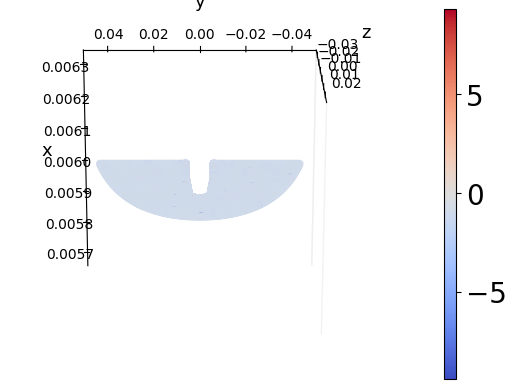

	-Std:


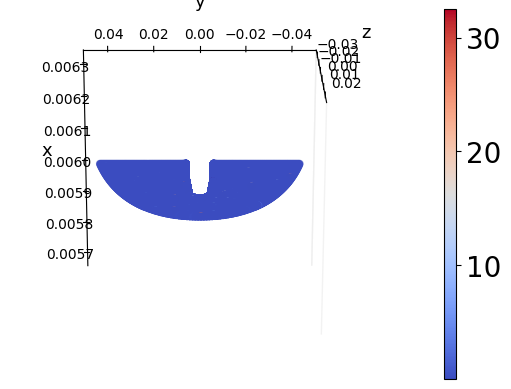

'\n# LDGN inference\nsteps = dgn.nn.diffusion.DiffusionStepsGenerator(\'linear\', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS)\npred = LDGN.sample_n(NUM_SAMPLES, graph, steps=steps, batch_size=BATCH_SIZE).cpu().squeeze(-1)\nmean = pred.mean(dim=1)\nstd  = pred.std (dim=1)\n# Compute the accuracy of the mean and std\nmean_r2 = dgn.metrics.r2_accuracy(mean, gt_mean)\nstd_r2  = dgn.metrics.r2_accuracy(std , gt_std )\nprint(\'====== LDGN ======\')\nprint(f"R2 of mean: {mean_r2:.4f}", f"R2 of std: {std_r2:.4f}")\n# Compute the Wasserstein-2 distance\nw2_distance_1d = dgn.metrics.w2_distance_1d(pred, graph.target)\nw2_distance_nd = dgn.metrics.w2_distance_nd(pred, graph.target)\nprint(f"Wasserstein-2 distance 1d: {w2_distance_1d:.4f}")\nprint(f"Wasserstein-2 distance nd: {w2_distance_nd:.4f}")\n# Plot the results\nprint(\'\t-Mean:\')\ngraph.plot_pos_field(mean, s=20, azim=180, elev=110)\nprint(\'\t-Std:\')\ngraph.plot_pos_field(std , s=20, azim=180, elev=110)\n# Save as vtk\n# This 

In [13]:
NUM_SAMPLES = 10
BATCH_SIZE  = 30 # Number of samples generated in parallel. Reduce this number if you run out of memory.


graph = dataset.get_sequence(SIM_IDX, n_in=T)
gt_mean = graph.target.mean(dim=1)
gt_std  = graph.target.std (dim=1)


# DGN inference
steps = dgn.nn.diffusion.DiffusionStepsGenerator('linear', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS)
pred = DGN.sample_n(NUM_SAMPLES, graph, steps=steps, batch_size=BATCH_SIZE).cpu().squeeze(-1)
mean = pred.mean(dim=1)
std  = pred.std (dim=1)
# Compute the accuracy of the mean and std
mean_r2 = dgn.metrics.r2_accuracy(mean, gt_mean)
std_r2  = dgn.metrics.r2_accuracy(std , gt_std )
print('====== DGN ======')
print(f"R2 of mean: {mean_r2:.4f}", f"R2 of std: {std_r2:.4f}")
# Compute the Wasserstein-2 distance
w2_distance_1d = dgn.metrics.w2_distance_1d(pred, graph.target)
w2_distance_nd = dgn.metrics.w2_distance_nd(pred, graph.target)
print(f"Wasserstein-2 distance 1d: {w2_distance_1d:.4f}")
print(f"Wasserstein-2 distance nd: {w2_distance_nd:.4f}")
# Plot the results
print('\t-Mean:')
graph.plot_pos_field(mean, s=20, azim=180, elev=110)
print('\t-Std:')
graph.plot_pos_field(std , s=20, azim=180, elev=110)
# Save as vtk
# This creates a point cloud. To visualize it in Paraview, use the 'Point Gaussian' representation or create a mesh with the 'Delaunay 3D' filter
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = mean,
    filename  = 'dgn_mean.vtk',
    fieldname = 'mean',
)
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = std,
    filename  = 'dgn_std.vtk',
    fieldname = 'std',
)

"""
# LDGN inference
steps = dgn.nn.diffusion.DiffusionStepsGenerator('linear', DGN.diffusion_process.num_steps)(NUM_DENOISING_STEPS)
pred = LDGN.sample_n(NUM_SAMPLES, graph, steps=steps, batch_size=BATCH_SIZE).cpu().squeeze(-1)
mean = pred.mean(dim=1)
std  = pred.std (dim=1)
# Compute the accuracy of the mean and std
mean_r2 = dgn.metrics.r2_accuracy(mean, gt_mean)
std_r2  = dgn.metrics.r2_accuracy(std , gt_std )
print('====== LDGN ======')
print(f"R2 of mean: {mean_r2:.4f}", f"R2 of std: {std_r2:.4f}")
# Compute the Wasserstein-2 distance
w2_distance_1d = dgn.metrics.w2_distance_1d(pred, graph.target)
w2_distance_nd = dgn.metrics.w2_distance_nd(pred, graph.target)
print(f"Wasserstein-2 distance 1d: {w2_distance_1d:.4f}")
print(f"Wasserstein-2 distance nd: {w2_distance_nd:.4f}")
# Plot the results
print('\t-Mean:')
graph.plot_pos_field(mean, s=20, azim=180, elev=110)
print('\t-Std:')
graph.plot_pos_field(std , s=20, azim=180, elev=110)
# Save as vtk
# This creates a point cloud. To visualize it in Paraview, use the 'Point Gaussian' representation or create a mesh with the 'Delaunay 3D' filter
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = mean,
    filename  = 'ldgn_mean.vtk',
    fieldname = 'mean',
)
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = std,
    filename  = 'ldgn_std.vtk',
    fieldname = 'std',
)


# Flow-Mathcing GNN inference
steps = np.linspace(0, 1, NUM_DENOISING_STEPS + 1)
pred = FMGN.sample_n(NUM_SAMPLES, graph, steps=steps, batch_size=BATCH_SIZE).cpu().squeeze(-1)
mean = pred.mean(dim=1)
std  = pred.std (dim=1)
# Compute the accuracy of the mean and std
mean_r2 = dgn.metrics.r2_accuracy(mean, gt_mean)
std_r2  = dgn.metrics.r2_accuracy(std , gt_std )
print('====== Flow-Matching GNN ======')
print(f"R2 of mean: {mean_r2:.4f}", f"R2 of std: {std_r2:.4f}")
# Compute the Wasserstein-2 distance
w2_distance_1d = dgn.metrics.w2_distance_1d(pred, graph.target)
w2_distance_nd = dgn.metrics.w2_distance_nd(pred, graph.target)
print(f"Wasserstein-2 distance 1d: {w2_distance_1d:.4f}")
print(f"Wasserstein-2 distance nd: {w2_distance_nd:.4f}")
# Plot the results
print('\t-Mean:')
graph.plot_pos_field(mean, s=20, azim=180, elev=110)
print('\t-Std:')
graph.plot_pos_field(std , s=20, azim=180, elev=110)
# Save as vtk
# This creates a point cloud. To visualize it in Paraview, use the 'Point Gaussian' representation or create a mesh with the 'Delaunay 3D' filter
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = mean,
    filename  = 'fmgn_mean.vtk',
    fieldname = 'mean',
)
dgn.plot.convert_to_vtk(
    pos       = graph.pos,
    fields    = std,
    filename  = 'fmgn_std.vtk',
    fieldname = 'std',
)
"""